# Módulo de Matemáticas 101: práctica

Vamos a poner de nuevo en práctica lo que hemos visto en este módulo. La práctica se centra en la regresión lineal (¡tema muy importante!) y podéis preguntarme las dudas que tengáis por Discord. ¡Mucha suerte!

## 1. Regresión lineal con mínimos cuadrados

En este ejercicio vamos a implementar la forma matricial de la regresión lineal con el método de los mínimos cuadrados. Para ello, tendrás que:

- Explorar un dataset
- Implementar la regresión lineal
- Aplicarla a un dataset concreto

Como recordatorio, los valores de los pesos $\widehat{w}$ vienen dados por:

<center>$\widehat{w} = (X^T X)^{-1}X^T y,$</center>

Donde $y$ es la variable a predecir y $X$ la matriz de features (NOTA: revisa cómo se define en los apuntes). Sabemos que los pesos van a ser los parámetros de la ecuación lineal que estamos intentando ajustar y tendremos uno por cada variable de entrada que usemos y además un término independiente o bias.

### 1.1 Carga del dataset y exploración de datos

Vamos a usar el dataset de [Auto MPG](https://archive.ics.uci.edu/dataset/9/auto+mpg) que podemos encontrar en el [repositorio de Machine learning de UC Irvine](https://archive.ics.uci.edu/). Lo primero, vamos a familiarizarnos con los datos.

En el propio repositorio nos indican cómo descargar el dataset con su librería (podemos consultar el código fuente si queremos).

In [1]:
!pip install ucimlrepo

zsh:1: command not found: pip


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
auto_mpg = fetch_ucirepo(id=9) 
  
# data (as pandas dataframes) 
X = auto_mpg.data.features 
y = auto_mpg.data.targets 
  
# metadata 
print(auto_mpg.metadata) 
  
# variable information 
print(auto_mpg.variables) 


{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

Con la función `head` de Pandas podemos ver las primeras filas del dataset.

In [3]:
X.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1


In [4]:
y.head()

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


En este punto, puedes hacer cualquier otro análisis exploratorio que creas conveniente.

A continuación, crea una función a la que le pases los dataframes de features y de target y el nombre de la variable y haga la gráfica del target (consumo en millas por galón) vs la variable que le ha llegado por parámetro. Puedes ver un ejemplo de gráfica más abajo, pero usa los parámetros que quieras en cuanto a color de los puntos, grids etc.

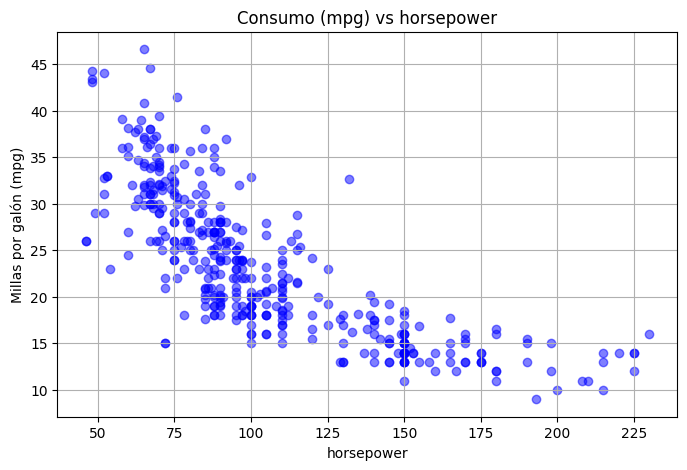

In [5]:
import matplotlib.pyplot as plt

def visualiza(df, y, nombre_columna):
    plt.figure(figsize=(8, 5))
    plt.scatter(df[nombre_columna], y, color='blue', alpha=0.5)
    plt.title(f'Consumo (mpg) vs {nombre_columna}')
    plt.xlabel(nombre_columna)
    plt.ylabel('Millas por galón (mpg)')
    plt.grid(True)
    plt.show()

visualiza(X, y, 'horsepower')

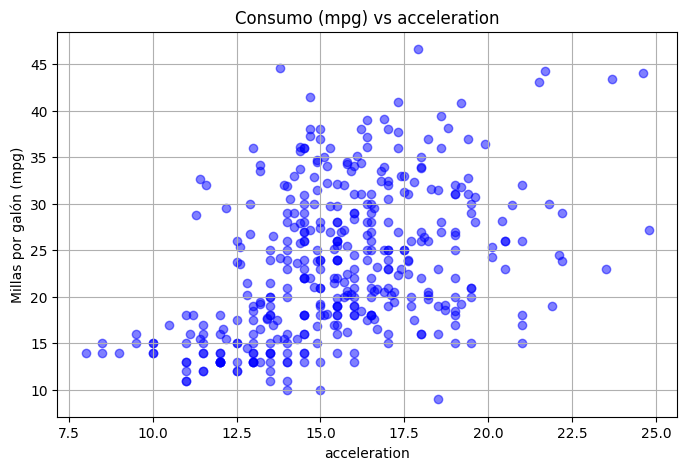

In [6]:
visualiza(X, y, 'acceleration')

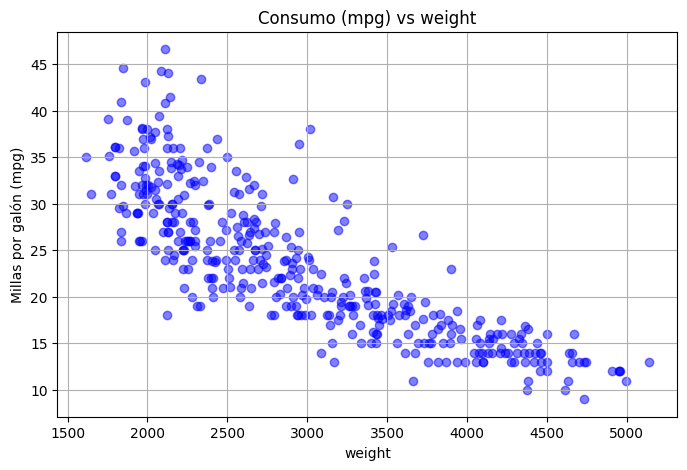

In [7]:
visualiza(X, y, 'weight')

IMPORTANTE: Aunque lo ideal sería un modelo multivariante, vamos a elegir la variable `weight` y hacer una regresión lineal solo con esta variable.

### 1.2 Implementación del modelo

En este punto vamos a dar un paso atrás y olvidarnos de los datos de consumo por un momento, porque el algoritmo que vamos a implementar serviría para cualquier conjunto de datos.

Lo primero, implementa una función que devuelva los valores de $\widehat{w}$ dados X e y. Si se da el caso de que el dataset tiene más features que observaciones, lo mostramos por pantalla y salimos de la función. Lo hacemos porque, como vimos en clase, los resultados no van a ser buenos si el número de observaciones es menor.

In [8]:
import numpy as np

def pesos_ols(X, y):
    # Comprobamos que hay más filas que columnas
    if X.shape[0] < X.shape[1]:
        print("Error: El dataset tiene más features que observaciones.")
        return None
    
    # Añadimos la columna de 1s para el bias
    ones = np.ones((X.shape[0], 1))
    X_expanded = np.hstack((ones, X))

    # Calculamos los pesos con la fórmula: (X^T * X)^-1 * X^T * y
    Xt = X_expanded.T
    w = np.linalg.inv(Xt @ X_expanded) @ Xt @ y #usamos esto para que calcule la matriz inversa, haga que las filas sean columnas y multiplicamos con @ 

    return w

In [9]:
# Arrays de prueba!! No son dataset reales y no hace falta que los dibujemos
X_prueba = np.array([[1710, 1262, 1786, 1717, 2198, 1362, 1694, 2090, 1774, 1077], 
              [2003, 1976, 2001, 1915, 2000, 1993, 2004, 1973, 1931, 1939]])
y_prueba = np.array([208500, 181500, 223500, 140000, 250000, 143000, 307000, 200000, 129900, 118000])
pesos_ols(X_prueba, y_prueba)

Error: El dataset tiene más features que observaciones.


In [10]:
X_prueba = np.array([[1710, 1262, 1786, 1717, 2198, 1362, 1694, 2090, 1774, 1077], 
              [2003, 1976, 2001, 1915, 2000, 1993, 2004, 1973, 1931, 1939]]).reshape(10,2)
y_prueba = np.array([208500, 181500, 223500, 140000, 250000, 143000, 307000, 200000, 129900, 118000])
pesos_ols(X_prueba, y_prueba)

array([ 1.98968523e+05,  7.36278026e+01, -8.63759760e+01])

Hasta aquí hemos implementado el algoritmo de mínimos cuadrados y lo hemos probado en un array de tamaño 2x10, pero aún no lo hemos probado con ningún dataset real. 

### 1.3 Prueba del modelo en los datos de consumo de coches

Ahora sí, ya podemos usar nuestra función `pesos` en el dataset real que hemos descargado, el de consumo de combustible. Para ver el ajuste, dibuja de nuevo los datos junto con la recta que has obtenido, en la misma gráfica. Tendrás que convertir los dataframes de Pandas en arrays de numpy para poder aplicar las operaciones matriciales.

TIP: Revisa las dimensiones de todos los arrays para ver que son correctas.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 10.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 11.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


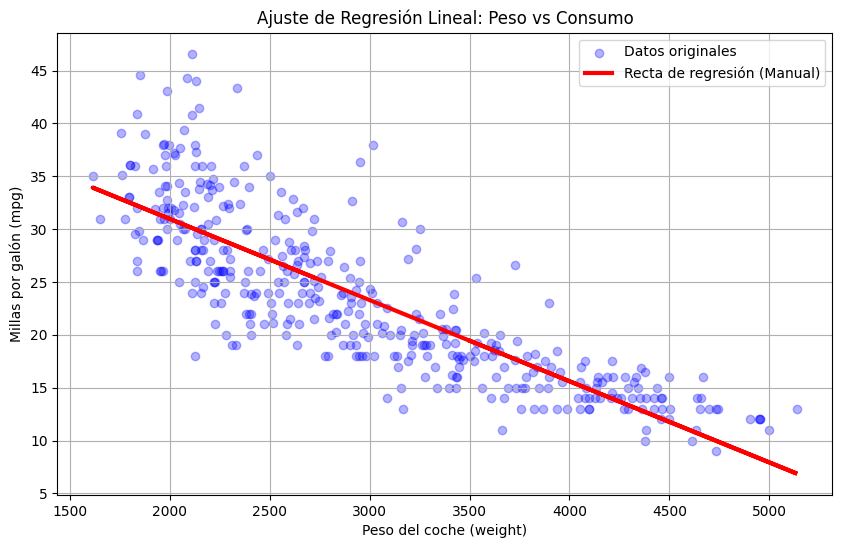

Intercepto (w0): 46.31736442026563
Pendiente (w1): -0.00767661006392646


In [14]:
# TODO Aplica el modelo y dibuja la recta junto con los datos

import numpy as np
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install scikit-learn #inserto esto porque me daba error en el siguiente paso

# para preparar los datos convertimos a arrays de numpy y seleccionamos 'weight'
X_real = X[['weight']].to_numpy()
y_real = y.to_numpy()

#Aplicamosfunción de pesos_ols
# Esto calcula w0 (intercept) y w1 (pendiente)
w_calculados = pesos_ols(X_real, y_real)

#Creamos la recta de predicción
# Necesitamos añadir otra columna de 1s para multiplicar por los pesos
X_plot = np.hstack((np.ones((X_real.shape[0], 1)), X_real))
y_predichas = X_plot @ w_calculados

#Dibujamos la gráfica
plt.figure(figsize=(10, 6))
plt.scatter(X_real, y_real, color='blue', alpha=0.3, label='Datos originales')
plt.plot(X_real, y_predichas, color='red', linewidth=3, label='Recta de regresión (Manual)')
plt.title('Ajuste de Regresión Lineal: Peso vs Consumo')
plt.xlabel('Peso del coche (weight)')
plt.ylabel('Millas por galón (mpg)')
plt.legend()
plt.grid(True)
plt.show()

#Imprimimos los resultados para comparar después con sklearn
print(f"Intercepto (w0): {w_calculados[0][0]}")
print(f"Pendiente (w1): {w_calculados[1][0]}")

Por último, vamos a comprar el resultado con el que nos da `scikit-learn`para ver si nuestra implementación tiene buena pinta. Podemos ver cómo funciona en la [documentación](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

In [15]:
from sklearn.linear_model import LinearRegression

# Creamos el objeto
lr = LinearRegression()

# Le pasamos los datos en el formato correcto
X = auto_mpg.data.features 
y = auto_mpg.data.targets 

X_lr = X[['weight']]
y_lr = y

# Entrenamos con los datos
lr.fit(X_lr,y_lr)
print("Punto de corte:", lr.intercept_)
print("Pendiente:", lr.coef_)

Punto de corte: [46.31736442]
Pendiente: [[-0.00767661]]


**TODO**: Analiza el resultado obtenido y compáralo con el de sklearn (solo hay que ver si coincide o no para saber si te has equivocado en algún punto). Si coincide, ¡enhorabuena! Ya sabes implementar tu primer modelo de Machine Learning desde la base.

### 1.4 Compara el método de mínimos cuadrados y el descenso del gradiente para obtener los coeficientes de una regresión lineal



Como el resultado de los pesos coincide con scikit, confirmamos que la aplciacion de la formula funciona. Si observamos los scatter plots, vemos una clara relacion negativa entre el peso del vehiculo y su eficiencia. 

## 2. Optimización con descenso del gradiente

Vamos a resolver el mismo problema usando el descenso del gradiente en lugar de la solución analítica. El descenso del gradiente es un método de optimización iterativo que usa el operador gradiente.

Como es iterativo, necesitamos decirle cuándo tiene que parar y darnos la solución. En este caso, le vamos a decir que pare y nos devuelva la solución después de un número de iteraciones que le pasaremos como parámetro. La ecuación iterativa es.

$$w^{t+1} = w^t - \eta \cdot \nabla f(w)$$

donde f es nuestra función objetivo, y w es un vector. Para la función objetivo, vamos a usar el error RSS, que querremos minimizar.

$$ RSS(w) = \frac{1}{2}\sum_{n=1}^{N}[y_n-f(x_n)]^2$$

y cuyo gradiente es:

$$\nabla RSS(w) = X^T(Xw^t-y)$$

TIP: Ten en cuenta que el RSS también lo puedes escribir como $\frac{1}{2}\sum_{n=1}^{N}[y_n-\hat{y_n}]^2$ donde $\hat{y_n} = X \hat{w}$ en cada paso.

### 2.1 Implementar el descenso del gradiente

Completa las siguientes funciones para implementar el descenso del gradiente con la función objetivo de la regresión lineal. La función necesitará:

- La entrada X y salida y de la regresión
- Un punto inicial desde el que empezar a iterar
- El número de iteraciones 
- El learning rate

La función nos devolverá un array con las w resultantes de las iteraciones y otro con el valor de la función en cada paso del algoritmo, a la que también se conoce como *loss function*.

In [27]:
import numpy as np

def gradient_descent(X, y, w0, n_iter, eta): 
    #columna de 1s para el bias
    X_exp = np.hstack((np.ones((X.shape[0], 1)), X))
    y = y.reshape(-1, 1)
    
    w = w0
    w_historial = [w0]
    loss_historial = []
    
    # Bucle
    for _ in range(n_iter):
        # Predicción y error
        y_hat = X_exp @ w
        error = y_hat - y
        
        # Guardamos error 
        loss = 0.5 * np.sum(error**2)
        loss_historial.append(loss)
        
        # Calculamos gradiente y actualizamos pesos
        gradiente = X_exp.T @ error
        w = w - eta * gradiente
        w_historial.append(w)
    
    return np.array(w_historial), np.array(loss_historial)

#probamos
eta, iteraciones = 0.01, 2000
np.random.seed(123)
w0 = np.random.rand(2, 1)

# Datos de prueba
y_test = np.array([208500, 181500, 223500, 140000, 250000]).reshape(-1, 1)
X_test = np.array([[0.37], [-0.48], [0.51], [0.38], [1.29]])

pesos, errores = gradient_descent(X_test, y_test, w0, iteraciones, eta)
print("Pesos finales:", pesos[-1])

Pesos finales: [[183850.47374139]
 [ 40699.33878882]]


### 2.2 Aplicar al dataset de consumo de combustible

Leemos de nuevo los datos y aplicamos la función que acabamos de programar.

In [24]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
auto_mpg = fetch_ucirepo(id=9) 
  
# data (as pandas dataframes) 
X = auto_mpg.data.features 
y = auto_mpg.data.targets 
  
# convert to numpy
X_np = X['weight'].to_numpy().reshape((X.shape[0], 1))
y_np = y.to_numpy()

print(X_np.shape)
print(y_np.shape)

(398, 1)
(398, 1)


Para ayudar al algoritmo, vamos a escalar la variable X, restando la media y dividiendo entre la desviación estándar. Después aplicamos la función anterior y dibujamos.

/var/folders/y0/thggx_596579ghf04t0nt1wm0000gn/T/ipykernel_93385/544994026.py:19: RuntimeWarning: overflow encountered in square
  loss = 0.5 * np.sum(error**2)


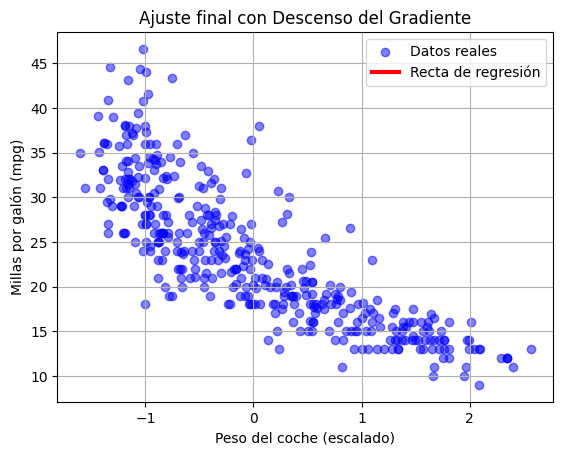

In [30]:
# TODO Aplica el modelo y dibuja la recta junto con los datos

X = auto_mpg.data.features
y = auto_mpg.data.targets

# Escalamos la variable x 

X_np = X['weight'].to_numpy().reshape((X.shape[0], 1))
y_np = y.to_numpy()

X_gd=(X_np - X_np.mean()) / X_np.std()
y_gd = y_np

# TODO 1: Punto inicial y learning rate
eta = 0.1                         # El paso de aprendizaje (learning rate)
iteraciones = 1000                # Cuántas veces se ajustará el modelo
np.random.seed(123)               # Para que el resultado sea siempre el mismo
w0 = np.random.rand(2, 1)         # Pesos iniciales aleatorios (bias y pendiente)

# TODO 2: Aplicamos el algoritmo
# Llamamos a la función que teniamos en anteriores pasos
weights, loss = gradient_descent(X_gd, y_gd, w0, iteraciones, eta)

# Guardamos el último peso obtenido para usarlo en la gráfica luego
w_final = weights[-1]

# Límites de los ejes
x_max = np.max(X_gd) + 1
x_min = np.min(X_gd) -1


# TODO 3 Dibuja la gráfica conjunta de la recta y los puntos (escalados)
import matplotlib.pyplot as plt

#Creamos una serie de puntos en el eje X para dibujar la recta
#Usamos linspace para generar 100 puntos entre el mínimo y el máximo
x_linea = np.linspace(x_min, x_max, 100)

#Calculamos los valores de Y usando la fórmula de la recta: y = w0 + w1 * x
#w_final[0] es el intercept y w_final[1] es la pendiente
y_linea = w_final[0] + w_final[1] * x_linea

#Dibujamos los puntos
plt.scatter(X_gd, y_gd, color='blue', alpha=0.5, label='Datos reales')

#Dibujamos la recta de nuestra predicción
plt.plot(x_linea, y_linea, color='red', linewidth=3, label='Recta de regresión')

# Añadimos nombres a los ejes y una leyenda
plt.xlabel('Peso del coche (escalado)')
plt.ylabel('Millas por galón (mpg)')
plt.title('Ajuste final con Descenso del Gradiente')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#el primer método devuelve los pesos exactos sin iteraciones, esta segunda parte 